In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

17030
17030


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: mondial


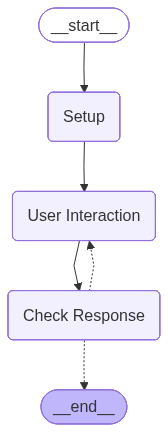

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    # Invoca a avaliação com as configurações estendidas
    eval_result = eval_graph.invoke({
        "experiment": experiment,
        "max_retries": 2,
        "debug_mode": True,
        "model_version": model_version,
        "experiment_type": experiment_type
    })

    print("Experimento avaliado:\n", eval_result["experiment_eval"])

    # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
    evals.append({
        "experiment_id": exp_id,
        "experiment_config": eval_result.get("experiment_config", {
            "max_retries": 2,
            "model_version": model_version,
            "timestamp": datetime.now().isoformat(),
            "experiment_type": experiment_type
        }),
        "experiment_eval": eval_result["experiment_eval"]
    })

    # Atualiza o arquivo salvando o resultado atual
    with open(evals_filename, 'w', encoding='utf-8') as f:
        json.dump(evals, f, indent=4)

Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 6 já processado.
Pulando experimento 7 já processado.
Pulando experimento 8 já processado.
Pulando experimento 9 já processado.
Pulando experimento 10 já processado.
Pulando experimento 11 já processado.
Pulando experimento 12 já processado.
Pulando experimento 13 já processado.
Pulando experimento 14 já processado.
Pulando experimento 15 já processado.
Pulando experimento 16 já processado.
Pulando experimento 17 já processado.
Pulando experimento 18 já processado.
Pulando experimento 19 já processado.
Pulando experimento 20 já processado.
Pulando experimento 21 já processado.
Pulando experimento 22 já processado.
Pulando experimento 23 já processado.
Pulando experimento 24 já processado.
Pulando experimento 25 já processado.
Pulando experimento 26 já processado.
Pulando experimento 2

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "List the cities that are located on islands.",
    "schema_linking": ["locatedon"],
    "answer": "There are 462 cities located on islands, including Aberdeen, Adamstown, Ajaccio, Akita, and Akureyri. The full list is extensive.",
    "sql": "SELECT  loc.city FROM mondial_gpt.locatedon loc;"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "List the cities that are located on islands.",
    "schema_linking": ["locatedon"],
    "answer": "There are 462 cities located on islands, including Aberdeen, Adamstown, Ajaccio, Akita, and Akureyri. The full list is extensive.",
    "sql": "SELECT  loc.city FROM mondial_gpt.locatedon loc;"
}.

[INFO] Avaliando o resultado: {'input': 'List the cities that are located on islands.', 'schema_linking': ['locatedon'], 'answer': 'There are 462 cities located on islands, including Aberdeen, Adamstown, Ajaccio, Akita, and A

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] Enviando a query para o agente:  Can you provide the cities along with the names of the islands they are located on?
Decomposition
['List the cities along with the names of the islands they are located on.', 'Quais são as cidades?', 'Quais são os nomes das ilhas onde as cidades estão localizadas?']
(17030,)
(17030,)
(17030,)
DFE
Question: Which cities can be found on islands in the database that lists mountains and islands?
SELECT DISTINCT MC.NAME
FROM MONDIAL_CITY MC
JOIN MONDIAL_PROVINCE MP ON MC.PROVINCE = MP.NAME
JOIN MONDIAL_GEO_MOUNTAIN MGM ON MP.NAME = MGM.PROVINCE
JOIN MONDIAL_MOUNTAINONISLAND MMOI ON MGM.MOUNTAIN = MMOI.MOUNTAIN;

Question: What are the names of the different islands listed in the database?
SELECT NAME FROM MONDIAL_ISLAND

Question: Which islands are included in the database with their respective names?
SELECT NAME FROM MONDIAL_ISLAND

Question: Which cities are situated on islands with volcanoes based on the type of island they are on?
SELECT DISTINCT 

...

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "Can you tell me the name and area of that sea?",
    "schema_linking": "",
    "answer": "The name of the largest sea is the Coral Sea, and its area is 4,791,000 square kilometers.",
    "sql": ""
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Can you tell me the name and area of that sea?",
    "schema_linking": "",
    "answer": "The name of the largest sea is the Coral Sea, and its area is 4,791,000 square kilometers.",
    "sql": ""
}.

[INFO] Avaliando o resultado: {'input': 'Can you tell me the name and area of that sea?', 'schema_linking': '', 'answer': 'The name of the largest sea is the Coral Sea, and its area is 4,791,000 square kilometers.', 'sql': ''}.

[AI as JUDGE] Judging if a feedback is needed for the last message in chat history.
[AI as JUDGE] Result: False.
[Schema Linking Recall calculus]
 Ground Truths: ['mondial_sea']
 Tables fr

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "Are there multiple seas with the largest area?",
    "schema_linking": ["Sea"],
    "answer": "No, there is only one sea with the largest area, which is the Coral Sea with an area of 4,791,000 square kilometers.",
    "sql": "SELECT name, area FROM mondial_gpt.sea WHERE area = (SELECT MAX(area) FROM mondial_gpt.sea)"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Are there multiple seas with the largest area?",
    "schema_linking": ["Sea"],
    "answer": "No, there is only one sea with the largest area, which is the Coral Sea with an area of 4,791,000 square kilometers.",
    "sql": "SELECT name, area FROM mondial_gpt.sea WHERE area = (SELECT MAX(area) FROM mondial_gpt.sea)"
}.

[INFO] Avaliando o resultado: {'input': 'Are there multiple seas with the largest area?', 'schema_linking': ['Sea'], 'answer': 'No, there is only one sea with the largest ar

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
